# Literature Comparison

In this notebook, we compare the performance of our model against the model from [Su et al.](https://pubs.rsc.org/en/content/articlelanding/2021/lc/d1lc00225b).

To run it, you will need to download the datasets from [this link](), and make sure the 

In [24]:
from pathlib import Path
import pickle
import sys; sys.path.insert(0,'../')

import lightning as L
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import tabulate

from src.config import Config
from src.model import LiftFNN
from src.datamodule import LiftDataModule

In [25]:
root_dir = Path("../")
data_dir = root_dir / "data" # <- Change this to point to your dataset directory

# Su
We have already trained this model and output the predictions into a .csv file, so we just need to load it, convert model outputs to enable comparison, and then run our performance testing pipeline.

If you want to see the training code, check out the [Matlab]() folder. 

In [26]:
df = pd.read_csv(data_dir / "lit_comparison" / "r_val_test_su_with_predictions.csv")
df = df.set_index("index")
df = df.reset_index(drop=True)
df.index.name = None

# Need to get some columns from the original dataset
valdf = pd.read_csv(root_dir / "experiments" / "su_comparison_3" / "r_val_test_no_rot.csv")
valdf = valdf.set_index("Unnamed: 0")
valdf = valdf.reset_index(drop=True)
valdf.index.name = None
valdf = valdf[["u", "umax", "a", "H"]]
df = valdf.join(df)

In [27]:
display(df.head())
print(len(df))

,u,umax,a,H,Var1,Var2,Var3,Var4,Var5,true_clx,true_cly,pred_clx,pred_cly
0,2.89820,3,7.5,50,4,0.15,148.554275,0.2,0.20,-0.000329,0.023505,-0.000643,0.023275
1,1.36690,2,15.0,50,1,0.30,99.036750,0.3,0.55,-0.021182,-0.008453,-0.015397,-0.007019
2,1.99610,4,10.0,50,2,0.20,198.076249,0.7,0.30,0.001747,-0.086269,-0.001882,-0.083338
3,0.99754,1,5.0,50,3,0.10,49.519819,0.1,0.10,0.003412,0.082128,0.005060,0.080165
4,0.48007,1,7.5,50,2,0.15,49.519167,0.7,0.40,-0.129655,-0.671351,-0.122477,-0.670391


2328


The authors use a slightly different lift force coefficient, so we need to convert their outputs to match ours. You can find out more in the [supplemental info]() of our paper.

In [28]:
df["pred_clx"] = df["pred_clx"] / ( df["u"] / ((df["umax"]**2) * (df["a"]**2) / (df["H"]**2)))
df["pred_cly"] = df["pred_cly"] / ( df["u"] / ((df["umax"]**2) * (df["a"]**2) / (df["H"]**2)))
df["pred_CL"] = np.sqrt(df["pred_clx"]**2 + df["pred_cly"]**2)

df["clx"] = df["true_clx"] / ( df["u"] / ((df["umax"]**2) * (df["a"]**2) / (df["H"]**2)))
df["cly"] = df["true_cly"] / ( df["u"] / ((df["umax"]**2) * (df["a"]**2) / (df["H"]**2)))
df["CL"] = np.sqrt(df["clx"]**2 + df["cly"]**2)

## Qualitative performance

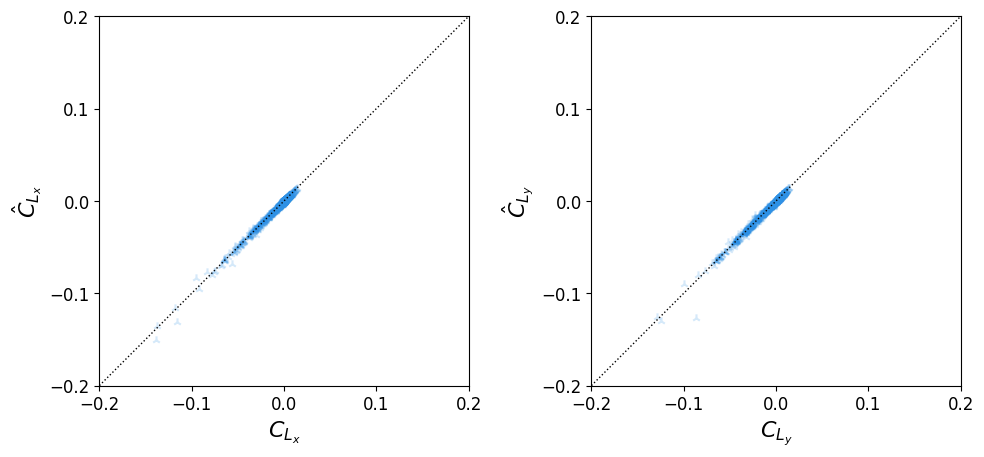

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# clx vs pred_clx
axs[0].scatter(df["clx"], df["pred_clx"], marker="2", alpha=0.2, color="#2E91E5")
axs[0].plot([-0.2, 0.2], [-0.2, 0.2], "k", linewidth=1, ls=":")  # y=x line
axs[0].set_xlabel(r"$C_{L_x}$", fontsize=16)
axs[0].set_ylabel(r"$\hat{C}_{L_x}$", fontsize=16)
axs[0].set_xlim(-0.2, 0.2)
axs[0].set_ylim(-0.2, 0.2)
axs[0].set_yticks(np.arange(-0.2, 0.3, 0.1))
axs[0].set_aspect("equal", adjustable="box")

# cly vs pred_cly
axs[1].scatter(df["cly"], df["pred_cly"], marker="2", alpha=0.2, color="#2E91E5")
axs[1].plot([-0.2, 0.2], [-0.2, 0.2], "k", linewidth=1, ls=":")
axs[1].set_xlabel(r"$C_{L_y}$", fontsize=16)
axs[1].set_ylabel(r"$\hat{C}_{L_y}$", fontsize=16)
axs[1].set_xlim(-0.2, 0.2)
axs[1].set_ylim(-0.2, 0.2)
axs[1].set_yticks(np.arange(-0.2, 0.3, 0.1))
axs[1].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

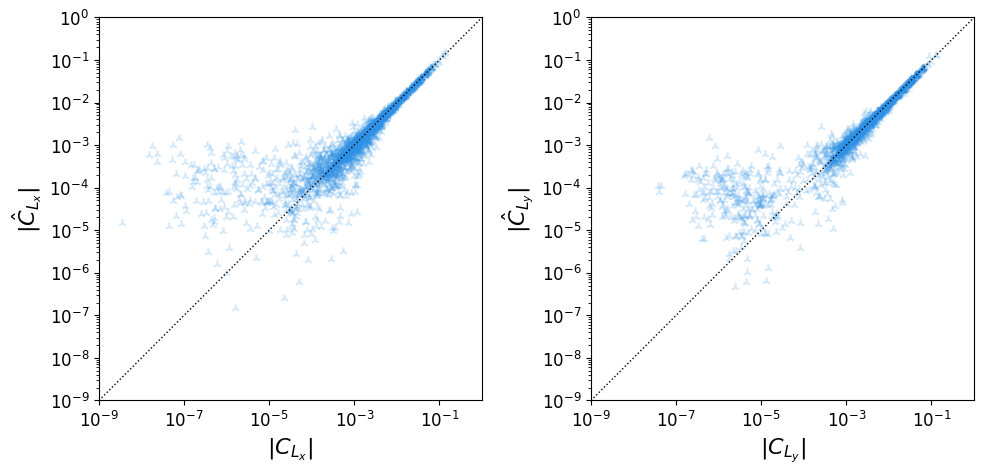

In [30]:
# Take absolute values for log scale
b = df[["clx", "cly", "pred_clx", "pred_cly"]].abs()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# clx vs pred_clx (log scale)
axs[0].scatter(b["clx"], b["pred_clx"], marker="2", alpha=0.2, color="#2E91E5")
axs[0].plot([1e-9, 1], [1e-9, 1], "k", linewidth=1, ls=":")  # y=x line
axs[0].set_xlabel(r"$|C_{L_x}|$", fontsize=16)
axs[0].set_ylabel(r"$|\hat{C}_{L_x}|$", fontsize=16)
axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].set_xlim(1e-9, 1)
axs[0].set_ylim(1e-9, 1)
axs[0].set_aspect("equal", adjustable="box")

# cly vs pred_cly (log scale)
axs[1].scatter(b["cly"], b["pred_cly"], marker="2", alpha=0.2, color="#2E91E5")
axs[1].plot([1e-9, 1], [1e-9, 1], "k", linewidth=1, ls=":")
axs[1].set_xlabel(r"$|C_{L_y}|$", fontsize=16)
axs[1].set_ylabel(r"$|\hat{C}_{L_y}|$", fontsize=16)
axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].set_xlim(1e-9, 1)
axs[1].set_ylim(1e-9, 1)
axs[1].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()


## Quantitative Performance

In [31]:
#For RMSE calculations
MSE = ((df['pred_clx'] - df['clx'])**2 + (df['pred_cly'] - df['cly'])**2)/2
MSE = np.mean(MSE)
RMSE = np.mean(MSE)**(1/2)

#For R2 calculations
Clx_avg = df['clx'].mean()
Cly_avg = df['cly'].mean()

R2_x = 1-np.sum((df['pred_clx']-df['clx'])**2)/np.sum((df['clx']-Clx_avg)**2)
R2_y = 1-np.sum((df['pred_cly']-df['cly'])**2)/np.sum((df['cly']-Cly_avg)**2)

#For theta_err calculations
pred_angle = np.arctan2(df["pred_clx"], df["pred_cly"])
actual_angle = np.arctan2(df["clx"], df["cly"])
theta_errs = np.abs(np.arctan2(
    np.sin(pred_angle - actual_angle),
    np.cos(pred_angle - actual_angle)
))

#For mag_err calculations
mag_errs = np.abs(df["CL"] - df["pred_CL"])/df["CL"]*100

err_df = pd.DataFrame({
    "theta_errs": theta_errs, 
    "mag_errs": mag_errs
    })

In [32]:
# Set quantile and get errors at q quantile
q = 0.95
tq = (err_df['theta_errs'].quantile(q=q))
tqd = tq * 180 / np.pi
mq = (err_df['mag_errs'].quantile(q=q))

# Get mean errors
mean_t = err_df['theta_errs'].mean()
mean_td = mean_t * 180 / np.pi
mean_m = err_df['mag_errs'].mean()

# Get median errors
t_med = err_df['theta_errs'].median()
t_med_d = t_med * 180 / np.pi
m_med = err_df['mag_errs'].median()

data = [
    ['MSE', '{:.3e}'.format(MSE)],
    ['RMSE', '{:.3e}'.format(RMSE)],
    ['R2_x', '{:.4f}'.format(R2_x)],
    ['R2_y', '{:.4f}'.format(R2_y)], 
    ["", ""],
    
    # Theta error in degrees
    ['theta (deg) q={:.3f}'.format(q), '{:.3f}'.format(tqd)],
    ['theta (deg) median', '{:.3f}'.format(t_med_d)], # Added Median
    ['theta (deg) mean', '{:.3f}'.format(mean_td)],
    ["", ""],

    # Theta error in radians
    ['theta (rad) median', '{:.3f}'.format(t_med)],
    ['theta (rad) mean', '{:.3f}'.format(mean_t)],
    ['theta (rad) std', '{:.3f}'.format(err_df['theta_errs'].std())],
    ["", ""],
    
    # Magnitude error in %
    ['mag q={:.3f}'.format(q), '{:.3f}%'.format(mq)],
    ['mag median', '{:.3f}%'.format(m_med)],           # Added Median
    ['mag mean', '{:.3f}%'.format(mean_m)],

]
table = tabulate.tabulate(data, tablefmt='html')
table

MSE,9.926e-07
RMSE,9.963e-04
R2_x,0.9952
R2_y,0.9928
,
theta (deg) q=0.950,17.614
theta (deg) median,2.245
theta (deg) mean,5.414
,
theta (rad) median,0.039
theta (rad) mean,0.094


In [33]:
su_err = err_df.copy()

# Ours

To run our model, we have to: 
1) Load the training config and scaler params
2) Load the checkpoint
3) Create the data module
4) Run the model on the data module

In [36]:
checkpoint_dir = root_dir / "checkpoints" / "r0"

In [37]:
# 1) Config and scaler
config = Config.from_yaml(checkpoint_dir / "config.yaml")

with (checkpoint_dir / "scaler.pkl").open("rb") as f: 
    scaler = pickle.load(f)

C:\Users\jesse_8eqas6o\OneDrive\Projects\programming\mf-lift\.venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [38]:
# 2) Load checkpoint
lift_model = LiftFNN.load_from_checkpoint(
    checkpoint_dir / "checkpoints" / "best.ckpt",
    hidden_layers=config.model.hidden_layers,
    learning_rate=config.training.learning_rate,
    lr_scheduler_patience=config.training.lr_scheduler_patience,
    lr_scheduler_factor=config.training.lr_scheduler_factor,
    n_inputs = len(config.data.feature_cols),
    n_outputs = len(config.data.target_cols)
)

In [42]:
# 3) Create the data module
data_path = root_dir / "data" / "lit_comparison" / "r_val_test_no_rot.csv"

data_module = LiftDataModule(
        feature_cols=config.data.feature_cols,
        target_cols=config.data.target_cols,
        train_path=config.paths.train_data,
        val_path=config.paths.val_data,
        test_path=config.paths.test_data,
        pred_path=data_path, # <--- The important one
        batch_size=config.data.batch_size,
        num_workers=config.data.num_workers,
        persistent_workers=config.data.persistent_workers,
        scaler = scaler
)

df = pd.read_csv(data_path) # Need the OG dataset to join some old columns

In [43]:
# Run the model 
trainer = L.Trainer();
preds = trainer.predict(lift_model, data_module)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\jesse_8eqas6o\OneDrive\Projects\programming\mf-lift\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting DataLoader 0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 73/73 [00:00<00:00, 220.08it/s]


In [44]:
# Construct df
preds = np.concatenate(preds, axis=0)
df[["pred_clx", "pred_cly"]] = preds
df["pred_CL"] = np.sqrt(df["pred_clx"]**2 + df["pred_cly"]**2)

# Original vectors
df["clx"] = df["nx"] * df["CL"]
df["cly"] = df["ny"] * df["CL"]

## Qualitative

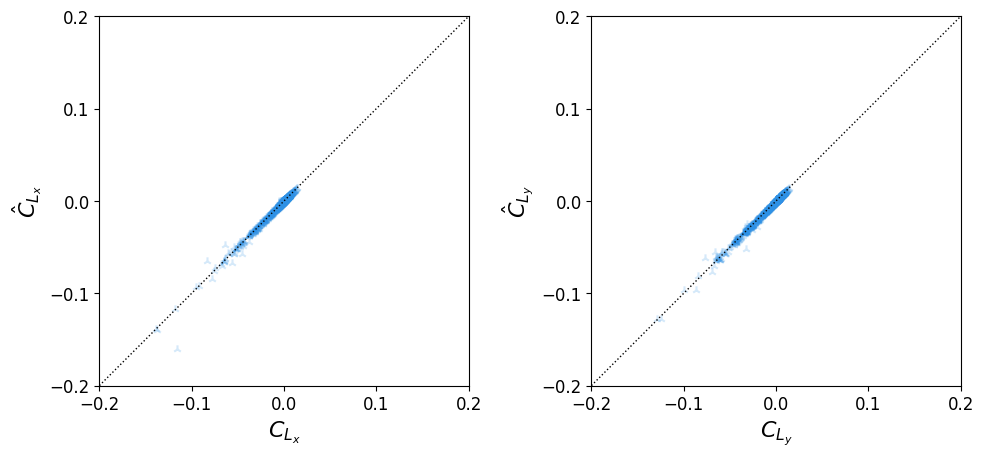

In [45]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# clx vs pred_clx
axs[0].scatter(df["clx"], df["pred_clx"], marker="2", alpha=0.2, color="#2E91E5")
axs[0].plot([-0.2, 0.2], [-0.2, 0.2], "k", linewidth=1, ls=":")  # y=x line
axs[0].set_xlabel(r"$C_{L_x}$", fontsize=16)
axs[0].set_ylabel(r"$\hat{C}_{L_x}$", fontsize=16)
axs[0].set_xlim(-0.2, 0.2)
axs[0].set_ylim(-0.2, 0.2)
axs[0].set_yticks(np.arange(-0.2, 0.3, 0.1))
axs[0].set_aspect("equal", adjustable="box")

# cly vs pred_cly
axs[1].scatter(df["cly"], df["pred_cly"], marker="2", alpha=0.2, color="#2E91E5")
axs[1].plot([-0.2, 0.2], [-0.2, 0.2], "k", linewidth=1, ls=":")
axs[1].set_xlabel(r"$C_{L_y}$", fontsize=16)
axs[1].set_ylabel(r"$\hat{C}_{L_y}$", fontsize=16)
axs[1].set_xlim(-0.2, 0.2)
axs[1].set_ylim(-0.2, 0.2)
axs[1].set_yticks(np.arange(-0.2, 0.3, 0.1))
axs[1].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()

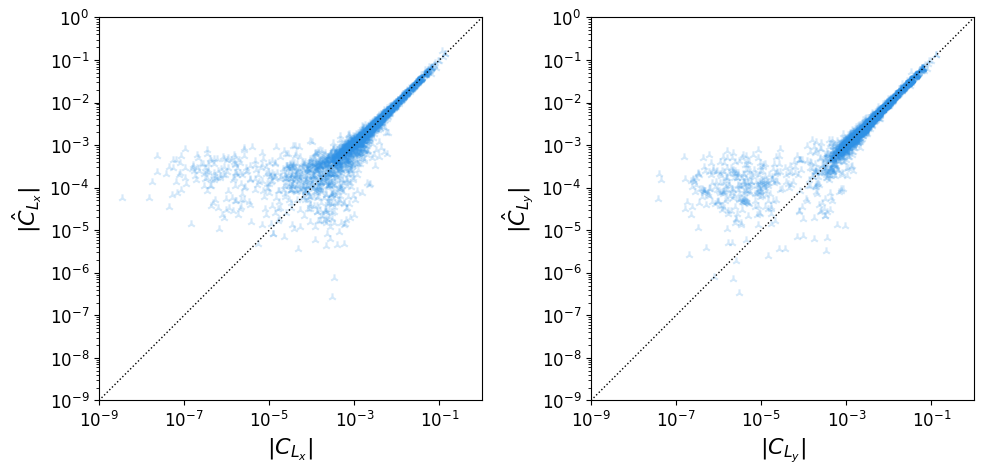

In [46]:
# Take absolute values for log scale
b = df[["clx", "cly", "pred_clx", "pred_cly"]].abs()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# clx vs pred_clx (log scale)
axs[0].scatter(b["clx"], b["pred_clx"], marker="2", alpha=0.2, color="#2E91E5")
axs[0].plot([1e-9, 1], [1e-9, 1], "k", linewidth=1, ls=":")  # y=x line
axs[0].set_xlabel(r"$|C_{L_x}|$", fontsize=16)
axs[0].set_ylabel(r"$|\hat{C}_{L_x}|$", fontsize=16)
axs[0].set_xscale("log")
axs[0].set_yscale("log")
axs[0].set_xlim(1e-9, 1)
axs[0].set_ylim(1e-9, 1)
axs[0].set_aspect("equal", adjustable="box")

# cly vs pred_cly (log scale)
axs[1].scatter(b["cly"], b["pred_cly"], marker="2", alpha=0.2, color="#2E91E5")
axs[1].plot([1e-9, 1], [1e-9, 1], "k", linewidth=1, ls=":")
axs[1].set_xlabel(r"$|C_{L_y}|$", fontsize=16)
axs[1].set_ylabel(r"$|\hat{C}_{L_y}|$", fontsize=16)
axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].set_xlim(1e-9, 1)
axs[1].set_ylim(1e-9, 1)
axs[1].set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.show()


## Quantitative

In [47]:
#For RMSE calculations
MSE = ((df['pred_clx'] - df['clx'])**2 + (df['pred_cly'] - df['cly'])**2)/2
MSE = np.mean(MSE)
RMSE = np.mean(MSE)**(1/2)

#For R2 calculations
Clx_avg = df['clx'].mean()
Cly_avg = df['cly'].mean()

R2_x = 1-np.sum((df['pred_clx']-df['clx'])**2)/np.sum((df['clx']-Clx_avg)**2)
R2_y = 1-np.sum((df['pred_cly']-df['cly'])**2)/np.sum((df['cly']-Cly_avg)**2)

#For theta_err calculations
pred_angle = np.arctan2(df["pred_clx"], df["pred_cly"])
actual_angle = np.arctan2(df["clx"], df["cly"])
theta_errs = np.abs(np.arctan2(
    np.sin(pred_angle - actual_angle),
    np.cos(pred_angle - actual_angle)
))

#For mag_err calculations
mag_errs = np.abs(df["CL"] - df["pred_CL"])/df["CL"]*100

err_df = pd.DataFrame({
    "theta_errs": theta_errs, 
    "mag_errs": mag_errs
    })

In [48]:
# Set quantile and get errors at q quantile
q = 0.95
tq = (err_df['theta_errs'].quantile(q=q))
tqd = tq * 180 / np.pi
mq = (err_df['mag_errs'].quantile(q=q))

# Get mean errors
mean_t = err_df['theta_errs'].mean()
mean_td = mean_t * 180 / np.pi
mean_m = err_df['mag_errs'].mean()

# Get median errors
t_med = err_df['theta_errs'].median()
t_med_d = t_med * 180 / np.pi
m_med = err_df['mag_errs'].median()

data = [
    ['MSE', '{:.3e}'.format(MSE)],
    ['RMSE', '{:.3e}'.format(RMSE)],
    ['R2_x', '{:.4f}'.format(R2_x)],
    ['R2_y', '{:.4f}'.format(R2_y)], 
    ["", ""],
    
    # Theta error in degrees
    ['theta (deg) q={:.3f}'.format(q), '{:.3f}'.format(tqd)],
    ['theta (deg) median', '{:.3f}'.format(t_med_d)], # Added Median
    ['theta (deg) mean', '{:.3f}'.format(mean_td)],
    ["", ""],

    # Theta error in radians
    ['theta (rad) median', '{:.3f}'.format(t_med)],
    ['theta (rad) mean', '{:.3f}'.format(mean_t)],
    ['theta (rad) std', '{:.3f}'.format(err_df['theta_errs'].std())],
    ["", ""],
    
    # Magnitude error in %
    ['mag q={:.3f}'.format(q), '{:.3f}%'.format(mq)],
    ['mag median', '{:.3f}%'.format(m_med)],           # Added Median
    ['mag mean', '{:.3f}%'.format(mean_m)],

]
table = tabulate.tabulate(data, tablefmt='html')
table

MSE,1.205e-06
RMSE,1.098e-03
R2_x,0.9890
R2_y,0.9955
,
theta (deg) q=0.950,22.143
theta (deg) median,3.166
theta (deg) mean,6.637
,
theta (rad) median,0.055
theta (rad) mean,0.116


In [49]:
our_err = err_df.copy()

# Comparison

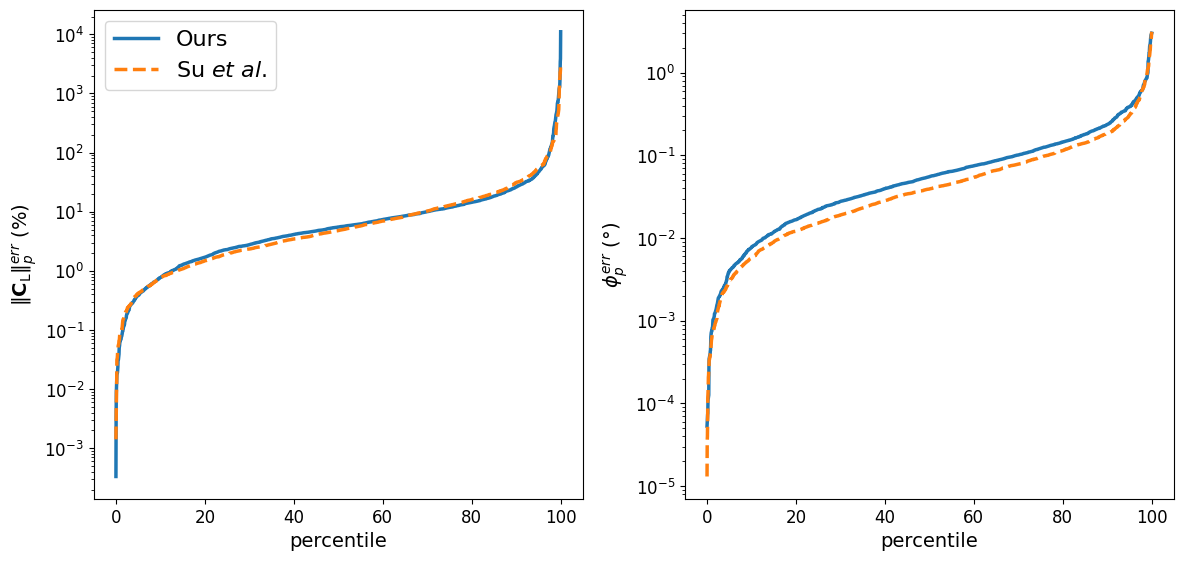

In [50]:
def plot_combined_performance(our_errs, su_errs):
    # Data prep
    metrics = [
        ('mag_errs', r'$\Vert\mathbf{C}_\mathrm{L}\Vert^{err}_p$ (%)'), 
        ('theta_errs', r'$\phi^{err}_p$ ($\degree$)')
    ]
    # Set global font size
    plt.rcParams.update({'font.size': 12})
    
    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    for i, (ax, (col, label)) in enumerate(zip(axes, metrics)):
        # Sort and create quantiles
        our_sorted = np.sort(our_errs[col])
        su_sorted = np.sort(su_errs[col])
        p = np.linspace(0, 100, len(our_sorted))
        
        # Plotting
        ax.plot(p, our_sorted, label='Ours', linewidth=2.5)
        ax.plot(p, su_sorted, label=r'Su $\mathit{et \ al.}$', linewidth=2.5, linestyle='--')
        
        # Formatting
        ax.set_yscale('log')
        ax.set_xlabel('percentile', fontsize=14)
        ax.set_ylabel(label, fontsize=14)
        ax.set_box_aspect(1)
        # ax.grid(True, which="major", ls="-", alpha=0.3)
        # Only show legend on the first plot
        if i == 0:
            ax.legend(fontsize=16, loc='upper left')

    plt.tight_layout()
    plt.savefig("performance_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

# Assuming your dataframes/dicts are named our_err and su_err
plot_combined_performance(our_err, su_err)